#  DBSCN 


a diferencia del k-mean que usa la clusterizacion para calcular la distancia ecludeana de sus vecinos, lo que hce el dbscan es 
sacar la densidad de esta con los hiper-parametros eps y min_cluster por cada uno de los cluster saca los valores minimos y dada a la 
distancia de la eps indica si la predicin se hizo de manera correcta 

# DBSCAN Scikit

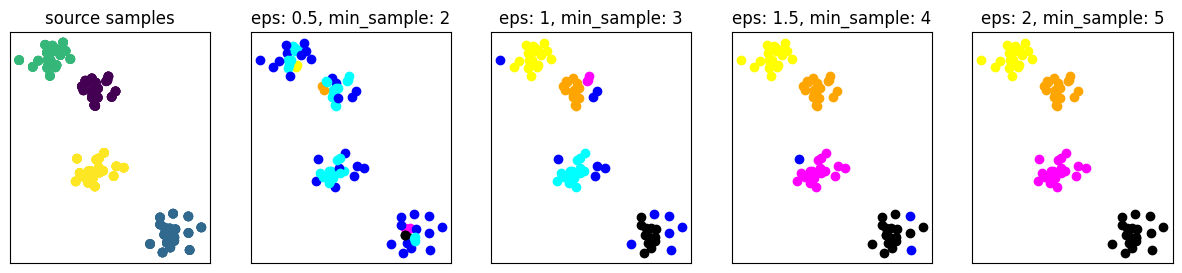

In [6]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

def color_cluster(i):
    colors = ('black', 'orange', 'yellow', 'magenta')
    if (i == -1):
        color = 'blue'
    else:
        if (i > NUM_CLASSES-1):
            color = 'cyan'
        else:
            color = colors[i]
    return color


NUM_CLASSES = 4
NUM_FEATURES = 2

X,y = make_blobs(n_samples=80, n_features=NUM_FEATURES, centers=NUM_CLASSES, cluster_std=1, random_state=14)

fig, axs = plt.subplots(1,NUM_CLASSES + 1, figsize=(15,3), subplot_kw={'xticks':(), 'yticks':()})

for f,eps, min_samples in zip(range(NUM_CLASSES), [0.5,1,1.5,2], [2,3,4,5]):
    dbscan_clustering = DBSCAN(eps=eps,min_samples=min_samples)
    clusters = dbscan_clustering.fit_predict(X)

    axs[0].scatter(X[:,0],X[:,1], c=y)
    axs[0].set_title('source samples')

    for i in range(len(y)):
        axs[f+1].scatter(X[i,0],X[i,1], c=color_cluster(clusters[i]))
        axs[f+1].set_title(f'eps: {str(eps)}, min_sample: {str(min_samples)}')


plt.show()


## Cluster Acumulativo

este tipo de cluster nos ayuda a acumular la mayoria de cluster posibles y a la vez tratar de juantarlos
una vez que esten lo suficientemente cerca entonces logra juntarlos y ajustar el modelo para mejorar su precison

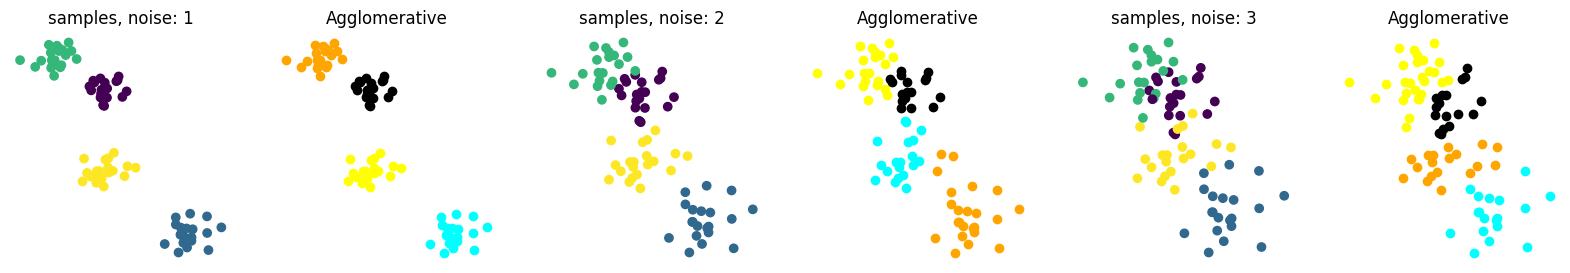

In [9]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

NUM_CLASSES = 4
NUM_FEATURES = 2

colors = ('orange','yellow', 'cyan', 'black')

fig, axs = plt.subplots(1,6,figsize=(20,3))

for desviation in [1,2,3]:
    X,y = make_blobs(n_samples=80, n_features=NUM_FEATURES, centers=NUM_CLASSES,
                     cluster_std=desviation, random_state=14)
    
    agl_clustering = AgglomerativeClustering(n_clusters=NUM_CLASSES)
    clusters = agl_clustering.fit_predict(X)

    axs[(desviation-1)*2].scatter(X[:,0], X[:,1], c=y)
    axs[(desviation-1)*2].set_title(f'samples, noise: {str(desviation)}')
    axs[(desviation-1)*2].axis("off")

    for i in range(len(y)):
        color = colors[clusters[i]]
        axs[(desviation-1)*2+1].scatter(X[i,0],X[i,1], c = color)
    
    axs[(desviation-1)*2+1].set_title('Agglomerative')
    axs[(desviation-1)*2+1].axis("off")
    
